In [1]:
import json
import os
import warnings
warnings.filterwarnings("ignore")
#!pip install opencv-python
#!pip install matplotlib
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelBinarizer

import tensorflow as tf
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# Optionally suppress other verbose logs
tf.get_logger().setLevel('ERROR')
from tensorflow.keras.models import Model

2025-03-31 14:46:15.699680: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-31 14:46:15.946359: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743446776.054299    3829 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743446776.078769    3829 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743446776.246719    3829 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
# Ensure TensorFlow uses GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Prevent full memory allocation
        tf.config.set_visible_devices(gpus[0], 'GPU')
        print("✅ GPU is now being used for TensorFlow!")
    except RuntimeError as e:
        print(e)

✅ GPU is now being used for TensorFlow!


In [3]:
cleaned_photos_df = pd.read_csv("../Dataset/cleaned_photos.csv")

In [4]:
import os
import re
import unicodedata
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from tqdm import tqdm
from transformers import TFBertModel, BertTokenizerFast, logging

# ============================
# Initial SetUp
# ============================
logging.set_verbosity_error()
bert_tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
bert_model = TFBertModel.from_pretrained("bert-base-uncased")

# ============================
# Caption Cleaning
# ============================
def clean_caption(text):
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8", "ignore")
    text = re.sub(r"[^\w\s.,!?'-]", "", text)
    text = re.sub(r"\s{2,}", " ", text)
    return text.strip()

def is_valid_caption(text):
    if not isinstance(text, str) or text.strip() == "":
        return False
    if re.match(r"^[A-Z][a-z]{2}-\d{2}$", text): return False
    if re.match(r"^\d+$", text): return False
    return True

def has_invalid_token(text, tokenizer):
    tokens = tokenizer.encode(text)
    return any(t >= tokenizer.vocab_size for t in tokens)

def prepare_clean_captions(df, tokenizer):
    df = df[df['label'] == 'drink']
    df = df[df['caption'].apply(is_valid_caption)].copy()
    df["caption"] = df["caption"].apply(clean_caption)
    df = df[~df["caption"].apply(lambda x: has_invalid_token(x, tokenizer))]
    return df.reset_index(drop=True)

# ============================
# Verify images
# ============================
def verificar_imagenes(photo_ids, captions, img_dir, image_size=(128, 128)):
    rutas_validas, captions_validas = [], []
    for pid, cap in tqdm(zip(photo_ids, captions), total=len(photo_ids), desc="🔍 Verifing images"):
        path = os.path.join(img_dir, f"{pid}.jpg")
        try:
            with Image.open(path) as img:
                img = img.convert("RGB").resize(image_size)
                np_img = np.array(img)
                if np_img.shape != (image_size[1], image_size[0], 3):
                    continue
                rutas_validas.append(pid)
                captions_validas.append(cap)
        except:
            continue
    return rutas_validas, captions_validas

# ============================
# 🤖 Embeddings con BERT (fuera del grafo)
# ============================
def get_bert_embeddings_numpy(captions, batch_size=64):
    all_embeddings = []
    for i in range(0, len(captions), batch_size):
        batch = captions[i:i+batch_size]
        encoded = bert_tokenizer(batch, padding=True, truncation=True, max_length=20, return_tensors="tf")
        outputs = bert_model(encoded["input_ids"], attention_mask=encoded["attention_mask"])
        cls_embeddings = outputs.last_hidden_state[:, 0, :].numpy().astype(np.float32)
        all_embeddings.append(cls_embeddings)
    return np.concatenate(all_embeddings, axis=0)

bert_proj = tf.keras.layers.Dense(768)

# ============================
# 🔁 Dataset Loader 
# ============================
def load_images_with_embeddings_numpy(photo_ids, embeddings, img_dir, image_size=(128, 128), batch_size=8):
    def process_image(image_path):
        try:
            img = tf.io.read_file(image_path)
            img = tf.image.decode_jpeg(img, channels=3)
            img = tf.image.resize(img, image_size)
            img = (tf.cast(img, tf.float32) / 127.5) - 1.0
        except:
            img = tf.zeros((*image_size, 3), dtype=tf.float32)
        return img

    image_paths = [os.path.join(img_dir, f"{pid}.jpg") for pid in photo_ids]
    imgs = tf.convert_to_tensor([process_image(p).numpy() for p in image_paths], dtype=tf.float32)
    emb_proj = bert_proj(tf.convert_to_tensor(embeddings))
    dataset = tf.data.Dataset.from_tensor_slices((imgs, emb_proj))
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# ============================
# 🔠 unet with cross attention
# ============================
from tensorflow.keras import layers, Model

class ConditionalUNetWithCrossAttention(Model):
    def __init__(self, text_embed_dim=768):
        super().__init__()
        self.conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')
        self.pool1 = layers.MaxPooling2D(2)
        self.attn = layers.MultiHeadAttention(num_heads=4, key_dim=64)
        self.conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')
        self.pool2 = layers.MaxPooling2D(2)
        self.conv3 = layers.Conv2D(256, 3, activation='relu', padding='same')
        self.up1 = layers.UpSampling2D(2)
        self.deconv1 = layers.Conv2D(128, 3, activation='relu', padding='same')
        self.up2 = layers.UpSampling2D(2)
        self.deconv2 = layers.Conv2D(64, 3, activation='relu', padding='same')
        self.final_conv = layers.Conv2D(3, 1, padding='same')

    def call(self, x, text_emb_seq):
        x = self.conv1(x)
        x = self.pool1(x)
        B, H, W, C = x.shape
        x_flat = tf.reshape(x, [B, H * W, C])
        attended = self.attn(query=x_flat, key=text_emb_seq, value=text_emb_seq)
        attended = tf.reshape(attended, [B, H, W, C])
        x = x + attended
        x = self.conv2(x)
        x = self.pool2(x)
        x = self.conv3(x)
        x = self.up1(x)
        x = self.deconv1(x)
        x = self.up2(x)
        x = self.deconv2(x)
        return self.final_conv(x)

# ============================
# 🎓 Diffusion Trainer
# ============================
class DiffusionTrainer(tf.keras.Model):
    def __init__(self, unet, timesteps=1000):
        super().__init__()
        self.unet = unet
        self.timesteps = timesteps
        beta = tf.linspace(1e-4, 0.02, timesteps)
        self.alpha = 1. - beta
        self.alpha_hat = tf.math.cumprod(self.alpha)
        self.loss_fn = tf.keras.losses.MeanSquaredError()
        self.optimizer = tf.keras.optimizers.Adam(1e-4)

    def add_noise(self, x0, t, noise):
        alpha_hat_t = tf.gather(self.alpha_hat, t)
        alpha_hat_t = tf.reshape(alpha_hat_t, (-1, 1, 1, 1))
        return tf.sqrt(alpha_hat_t) * x0 + tf.sqrt(1. - alpha_hat_t) * noise

    def train_step(self, batch):
        imgs, text_emb = batch
        batch_size = tf.shape(imgs)[0]
        t = tf.random.uniform(minval=0, maxval=self.timesteps, shape=[batch_size], dtype=tf.int32)
        noise = tf.random.normal(shape=tf.shape(imgs))
        x_t = self.add_noise(imgs, t, noise)

        text_emb = tf.expand_dims(text_emb, axis=1)

        with tf.GradientTape() as tape:
            pred_noise = self.unet(x_t, text_emb)
            loss = self.loss_fn(noise, pred_noise)

        grads = tape.gradient(loss, self.unet.trainable_variables + bert_proj.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.unet.trainable_variables + bert_proj.trainable_variables))
        return {"loss": loss}

# ============================
# ⏳ Entrenamiento
# ============================
def train_model(trainer, dataset, epochs=1):
    for epoch in range(epochs):
        print(f"\n🚀 Epoch {epoch+1}/{epochs}")
        epoch_loss = []
        for step, batch in enumerate(tqdm(dataset, desc=f"Epoch {epoch+1}")):
            logs = trainer.train_step(batch)
            epoch_loss.append(logs["loss"].numpy())
            if step % 10 == 0:
                print(f"  Step {step} - Loss: {logs['loss'].numpy():.4f}")
        print(f"✅ Avg Loss: {np.mean(epoch_loss):.4f}")


I0000 00:00:1743446785.671146    3829 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [6]:
df = pd.read_csv("../Dataset/cleaned_photos.csv")
drinks_df = df[df['label']=='drink']
df_clean = prepare_clean_captions(drinks_df, bert_tokenizer)

photo_ids = df_clean["photo_id"].tolist()
captions = df_clean["caption"].tolist()
img_dir = "../Dataset/photos"

photo_ids_valid, captions_valid = verificar_imagenes(photo_ids, captions, img_dir)

# Generate embeddings
embeddings = get_bert_embeddings_numpy(captions_valid)

# Final Dataset
dataset = load_images_with_embeddings_numpy(photo_ids_valid, embeddings, img_dir)

# Train
unet = ConditionalUNetWithCrossAttention()
trainer = DiffusionTrainer(unet)
train_model(trainer, dataset, epochs=20)


🔍 Verificando imágenes: 100%|██████████████████████████████████████████████████████| 7546/7546 [02:39<00:00, 47.36it/s]



🚀 Epoch 1/20


Epoch 1:   0%|▏                                                                         | 2/944 [00:01<08:31,  1.84it/s]

  Step 0 - Loss: 1.0952


Epoch 1:   1%|▉                                                                        | 12/944 [00:02<02:42,  5.75it/s]

...

  Step 930 - Loss: 0.5579


Epoch 20: 100%|██████████████████████████████████████████████████████████████████████▊| 942/944 [02:22<00:00,  7.72it/s]

  Step 940 - Loss: 0.5860


Epoch 20: 100%|███████████████████████████████████████████████████████████████████████| 944/944 [02:23<00:00,  6.59it/s]

✅ Avg Loss: 0.5915


In [7]:
def generate_image_from_caption(caption, unet, timesteps=1000):
    # Preproces text
    encoded = bert_tokenizer(caption, return_tensors="tf", padding='max_length', truncation=True, max_length=20)
    outputs = bert_model(encoded["input_ids"], attention_mask=encoded["attention_mask"])
    text_emb = outputs.last_hidden_state[:, 0, :]  # [CLS] embedding
    text_emb = bert_proj(text_emb)  # Proyection for UNet
    text_emb = tf.expand_dims(text_emb, axis=1)    # Expand dims for attention

    # Start with noise
    x = tf.random.normal((1, 128, 128, 3))

    alpha = tf.linspace(1e-4, 0.02, timesteps)
    alpha = 1. - alpha
    alpha_hat = tf.math.cumprod(alpha)

    for t in reversed(range(timesteps)):
        t_tensor = tf.constant([t], dtype=tf.int32)
        alpha_hat_t = tf.gather(alpha_hat, t_tensor)
        alpha_hat_t = tf.reshape(alpha_hat_t, (1, 1, 1, 1))

        pred_noise = unet(x, text_emb)

        x = (x - (1 - alpha_hat_t) ** 0.5 * pred_noise) / (alpha_hat_t ** 0.5)
        if t > 0:
            noise = tf.random.normal(shape=x.shape)
            x += (1 - alpha_hat_t) ** 0.5 * noise

    x = (x + 1) * 127.5
    x = tf.clip_by_value(x, 0, 255)
    img = tf.cast(x[0], tf.uint8).numpy()

    return Image.fromarray(img)


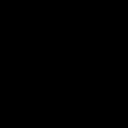

In [9]:
caption = "Iced Shaken Espresso"
generated_img = generate_image_from_caption(caption, unet)
generated_img.show()  # o .save("output.png")


# Assess the images

In [ ]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')

In [ ]:
mobilenet = tf.keras.applications.MobileNetV2(
    include_top=False,
    pooling='avg',
    input_shape=(224, 224, 3)
)

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

In [ ]:
def preprocess_for_mobilenet(images):
    images = tf.image.resize(images, [224, 224])
    return preprocess_input(images * 255.0)  # Scale from [0,1] → [0,255]

In [ ]:
def get_activations(images, batch_size=16):
    images = preprocess_for_mobilenet(images)
    activations = []
    for i in range(0, images.shape[0], batch_size):
        batch = images[i:i+batch_size]
        with tf.device('/CPU:0'):  # or remove this if you want to try GPU again
            feats = mobilenet(batch, training=False)
        activations.append(feats)
    return tf.concat(activations, axis=0)

In [ ]:
def calculate_fid(real_act, fake_act):
    # Flatten from [N, H, W, C] to [N, features]
    real_act = tf.reshape(real_act, [real_act.shape[0], -1]).numpy()
    fake_act = tf.reshape(fake_act, [fake_act.shape[0], -1]).numpy()

    mu1 = np.mean(real_act, axis=0)
    mu2 = np.mean(fake_act, axis=0)
    sigma1 = np.cov(real_act, rowvar=False)
    sigma2 = np.cov(fake_act, rowvar=False)

    diff = mu1 - mu2
    covmean, _ = sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    return diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)

In [ ]:
from scipy.stats import entropy

def calculate_inception_score(features, splits=10):
    preds = tf.nn.softmax(features).numpy()
    split_scores = []
    N = preds.shape[0]
    for k in range(splits):
        part = preds[k * (N // splits): (k + 1) * (N // splits), :]
        py = np.mean(part, axis=0)
        scores = [entropy(p, py) for p in part]
        split_scores.append(np.mean(scores))
    return np.exp(np.mean(split_scores))

In [ ]:
# Generate fake images from generator
def generate_fake_images(generator, num_images=1000, batch_size=100, noise_dim=100):
    fake_images = []
    for _ in range(num_images // batch_size):
        noise = tf.random.normal([batch_size, noise_dim])
        generated = generator(noise, training=False)
        generated = (generated + 1.0) / 2.0  
        fake_images.append(generated)
    return tf.concat(fake_images, axis=0)

# Get real images from training dataset
def get_real_images(dataset, num_images=1000):
    real_images = []
    for batch in dataset:
        batch = (batch + 1.0) / 2.0 
        real_images.append(batch)
        if sum(x.shape[0] for x in real_images) >= num_images:
            break
    return tf.concat(real_images, axis=0)[:num_images]

In [ ]:
fake_imgs = generate_fake_images(generator, num_images=1000)
real_imgs = get_real_images(train_dataset, num_images=1000)

act_fake = get_activations(fake_imgs)
act_real = get_activations(real_imgs)

fid_score = calculate_fid(act_real.numpy(), act_fake.numpy())
is_score = calculate_inception_score(fake_imgs)

print(f"Inception Score: {is_score:.4f}")
print(f"FID Score: {fid_score:.4f}")

In [ ]:
import matplotlib.pyplot as plt

def plot_generated_images(generator, num_images=5):
    noise = tf.random.normal([num_images, 100])
    generated_images = generator(noise, training=False)
    generated_images = (generated_images + 1.0) / 2.0  # Rescale to [0, 1]

    plt.figure(figsize=(15, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(generated_images[i])
        plt.axis('off')
    plt.show()


In [ ]:
plot_generated_images(generator)